<a href="https://colab.research.google.com/github/Himanshu86270/ML1/blob/main/Creditcard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving default of credit card clients.csv to default of credit card clients (1).csv


In [ ]:
df = pd.read_csv('default of credit card clients.csv')
df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
X9,0


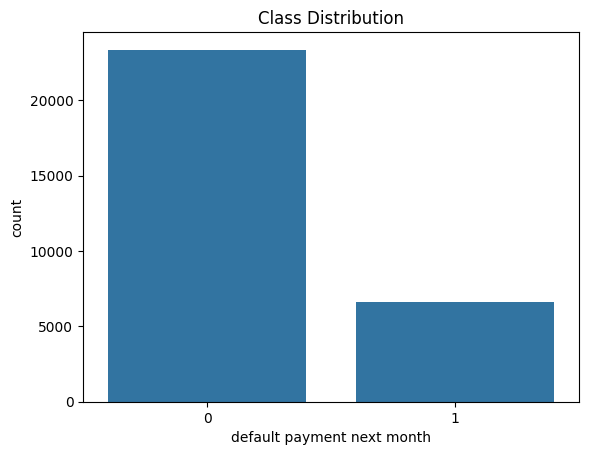

In [ ]:
new_columns = df.iloc[0]
df = df[1:].copy()
df.columns = new_columns
df = df.apply(pd.to_numeric, errors='coerce')
df.fillna(df.median(numeric_only=True), inplace=True)
sns.countplot(x="default payment next month", data=df)
plt.title("Class Distribution")
plt.show()

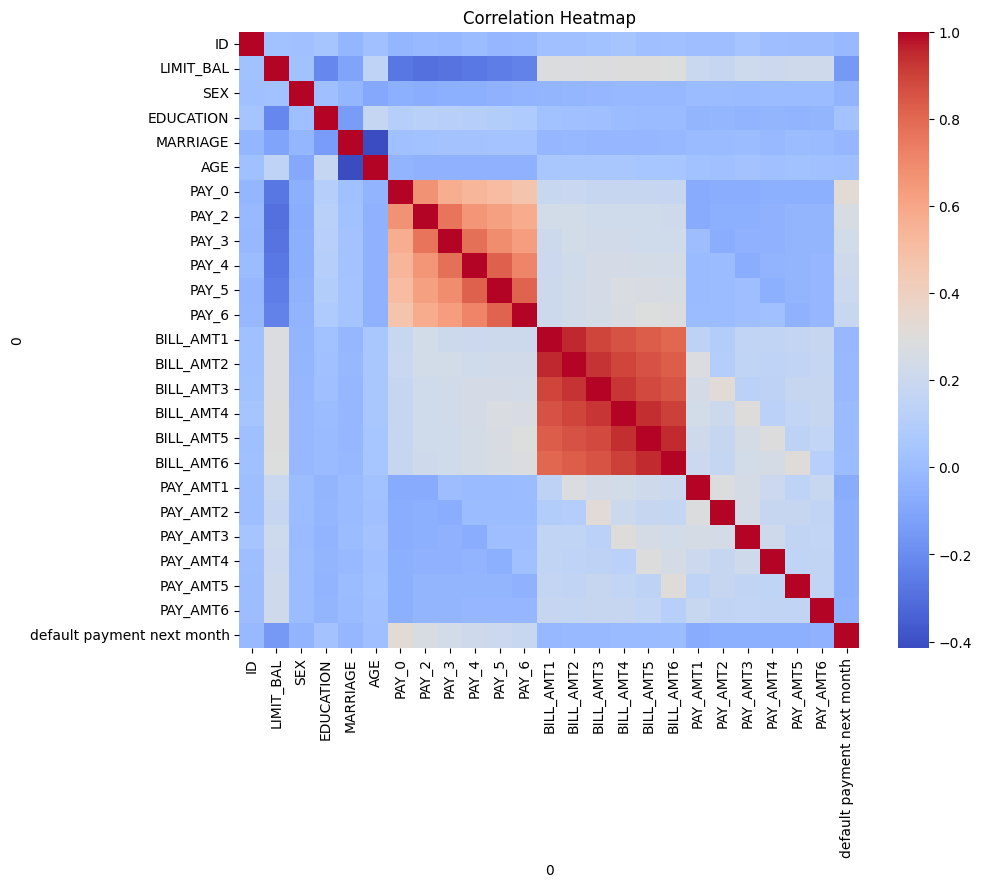

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm") # Use numeric_only for corr
plt.title("Correlation Heatmap")
plt.show()

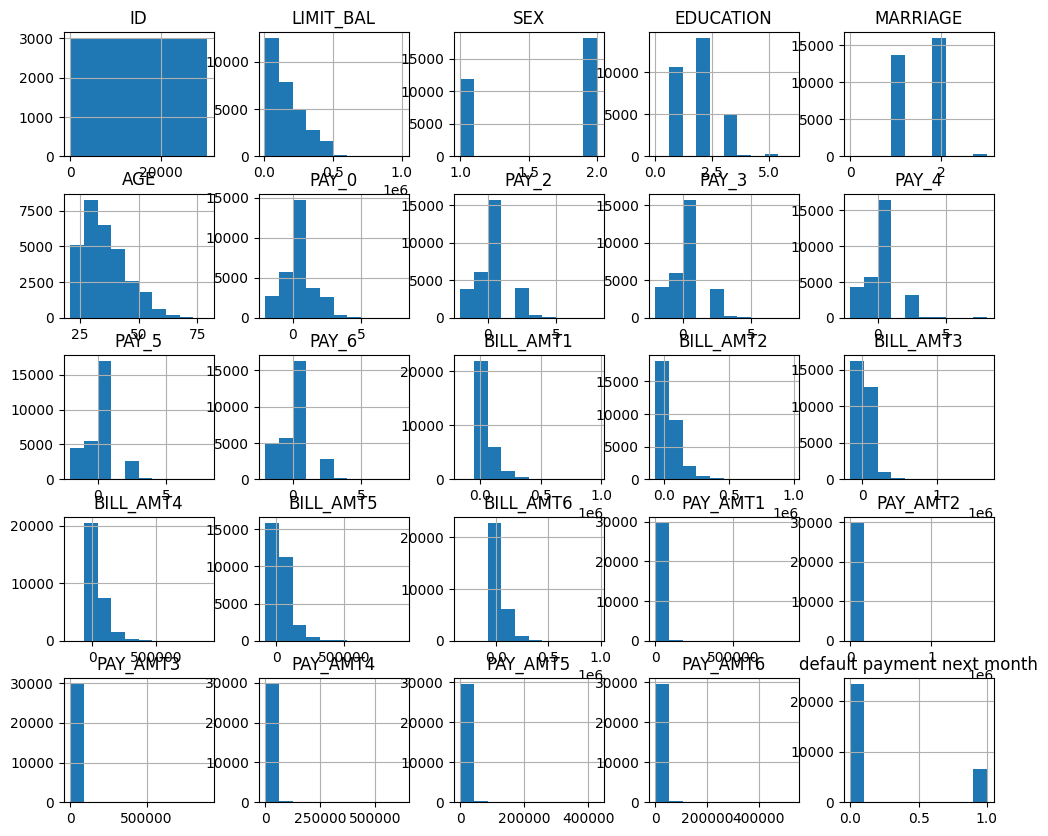

In [ ]:
df.hist(figsize=(12,10))
plt.show()

In [ ]:
X = df.drop("default payment next month", axis=1)
y = df["default payment next month"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = []

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:59:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"
])

print(results_df.sort_values(by="ROC-AUC", ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
3        Random Forest  0.787333   0.520715  0.483044  0.501173  0.746992
6    Gradient Boosting  0.759167   0.462940  0.555388  0.504967  0.741379
7              XGBoost  0.771667   0.483242  0.467219  0.475096  0.734222
4                  SVM  0.743333   0.437242  0.559156  0.490741  0.730369
5          Naive Bayes  0.447500   0.262315  0.826677  0.398257  0.704237
0  Logistic Regression  0.690000   0.371069  0.577995  0.451974  0.691426
1                  KNN  0.693500   0.370445  0.551620  0.443233  0.685620
2        Decision Tree  0.687000   0.347706  0.474002  0.401148  0.610744


In [ ]:
rf = RandomForestClassifier()

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(rf, param_grid, cv=5, scoring="roc_auc")
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Tuned ROC-AUC:",
      roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Tuned ROC-AUC: 0.7457908480647941


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    best_rf, X, y, cv=5, scoring="accuracy",
    train_sizes=np.linspace(0.1,1.0,5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

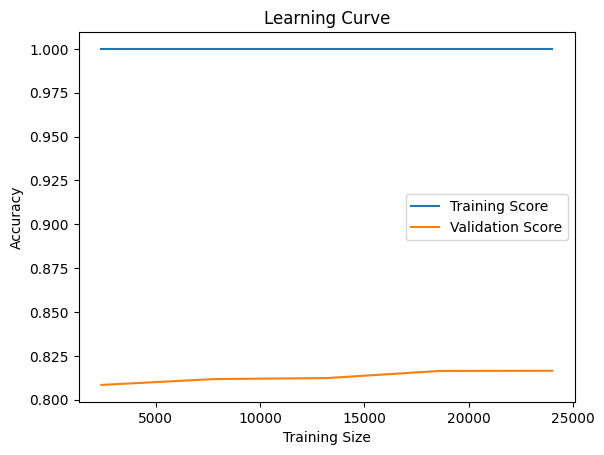

In [ ]:
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.legend()
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.show()

In [ ]:
best_model = results_df.sort_values(by="ROC-AUC", ascending=False).iloc[0]
print("Best Model Based on ROC-AUC:", best_model["Model"])

Best Model Based on ROC-AUC: Random Forest
